Task 1.1: Overview of Dataset

In [1]:
import pandas as pd

df = pd.read_csv("Dataset1.csv")

print("Total Records:", df.shape[0])
print("Total Columns:", df.shape[1])
print("Unique Trains:", df['Train_No'].nunique())

print(df.columns)

Total Records: 186074
Total Columns: 12
Unique Trains: 11113
Index(['SN', 'Train_No', 'Station_Code', '1A', '2A', '3A', 'SL',
       'Station_Name', 'Route_Number', 'Arrival_time', 'Departure_Time',
       'Distance'],
      dtype='object')


Task 1.2: List All Trains with Starting and Ending Stations

In [2]:
train_routes = df.groupby('Train_No').agg(
    Start_Station=('Station_Name', 'first'),
    End_Station=('Station_Name', 'last')
).reset_index()

print(train_routes.head())

   Train_No Start_Station   End_Station
0       107  SAWANTWADI R   MADGOAN JN.
1       108   MADGOAN JN.  SAWANTWADI R
2       128   MADGOAN JN.   CHHATRAPATI
3       290  DELHI-SAFDAR  DELHI-SAFDAR
4       401    AURANGABAD  VARANASI JN.


Task 1.3: Calculate Number of Stops Per Train

In [3]:
stops_per_train = df.groupby('Train_No')['Station_Name'].count()

stops_df = stops_per_train.reset_index()
stops_df.columns = ['Train_No', 'Number_of_Stops']

print(stops_df.head())

   Train_No  Number_of_Stops
0       107                4
1       108                4
2       128               22
3       290               14
4       401               12


Task 1.4: Identify Trains with Maximum and Minimum Stops

In [4]:
max_train = stops_df.loc[
    stops_df['Number_of_Stops'].idxmax()
]

min_train = stops_df.loc[
    stops_df['Number_of_Stops'].idxmin()
]

print("Maximum Stops Train:")
print(max_train)

print("\nMinimum Stops Train:")
print(min_train)

Maximum Stops Train:
Train_No           53041
Number_of_Stops      118
Name: 5977, dtype: int64

Minimum Stops Train:
Train_No           557
Number_of_Stops      2
Name: 11, dtype: int64


Level 2: Simple Data Processing

Task 2.1: Standardize Schedule Fields (Arrival & Departure Times)

In [5]:
import pandas as pd

df = pd.read_csv("Dataset1.csv")

# Convert time columns into datetime format
df['Arrival_time'] = pd.to_datetime(
    df['Arrival_time'],
    format='%H:%M:%S',
    errors='coerce'
)

df['Departure_Time'] = pd.to_datetime(
    df['Departure_Time'],
    format='%H:%M:%S',
    errors='coerce'
)

print(df[['Arrival_time', 'Departure_Time']].head())

         Arrival_time      Departure_Time
0 1900-01-01 00:00:00 1900-01-01 10:25:00
1 1900-01-01 11:06:00 1900-01-01 11:08:00
2 1900-01-01 11:28:00 1900-01-01 11:30:00
3 1900-01-01 12:10:00 1900-01-01 00:00:00
4 1900-01-01 00:00:00 1900-01-01 20:30:00


Task 2.2: Compute Total Journey Duration for Each Train

In [6]:
# Sort by train and distance
df = df.sort_values(['Train_No', 'Distance'])

journey_duration = []

for train, group in df.groupby('Train_No'):

    start_departure = group.iloc[0]['Departure_Time']
    end_arrival = group.iloc[-1]['Arrival_time']

    if pd.notna(start_departure) and pd.notna(end_arrival):

        duration = end_arrival - start_departure

        if duration.total_seconds() < 0:
            duration += pd.Timedelta(days=1)

        journey_duration.append(
            [train, duration]
        )

journey_df = pd.DataFrame(
    journey_duration,
    columns=['Train_No', 'Journey_Duration']
)

print(journey_df.head())

   Train_No Journey_Duration
0       107  0 days 01:45:00
1       108  0 days 01:55:00
2       128  0 days 22:05:00
3       290  0 days 08:00:00
4       401  0 days 12:30:00


Task 2.3: Classify Routes as Short, Medium, or Long

In [7]:
route_distance = df.groupby('Train_No')['Distance'].max().reset_index()

def classify_route(distance):

    if distance < 300:
        return "Short"

    elif distance <= 800:
        return "Medium"

    else:
        return "Long"

route_distance['Route_Type'] = route_distance['Distance'].apply(
    classify_route
)

print(route_distance.head())

   Train_No  Distance Route_Type
0       107        78      Short
1       108        83      Short
2       128       978       Long
3       290      2694       Long
4       401      1618       Long


Task 2.4: Generate Station-Wise Train Frequency Counts

In [8]:
station_frequency = df.groupby(
    'Station_Name'
)['Train_No'].nunique().reset_index()

station_frequency.columns = [
    'Station_Name',
    'Train_Frequency'
]

station_frequency = station_frequency.sort_values(
    'Train_Frequency',
    ascending=False
)

print(station_frequency.head(10))

      Station_Name  Train_Frequency
1755    CST-MUMBAI             1027
3466     KALYAN JN              828
7509         THANE              796
6834       SEALDAH              745
1592  CHENNAI BEAC              738
2950    HOWRAH JN.              699
1773         DADAR              598
2213   DUM DUM JN.              463
4245         KURLA              462
7401      TAMBARAM              434


Level 3: Data Quality Checks

Task 3.1: Handle missing schedule values

In [12]:
# Check missing values in all columns
print(df.isnull().sum())

SN                0
Train_No          0
Station_Code      0
1A                0
2A                0
3A                0
SL                0
Station_Name      0
Route_Number      0
Arrival_time      0
Departure_Time    0
Distance          0
dtype: int64


In [14]:
#Missing Values Summary
missing_values = df.isnull().sum()

missing_df = pd.DataFrame({
    'Column': missing_values.index,
    'Missing_Count': missing_values.values
})

print(missing_df)

            Column  Missing_Count
0               SN              0
1         Train_No              0
2     Station_Code              0
3               1A              0
4               2A              0
5               3A              0
6               SL              0
7     Station_Name              0
8     Route_Number              0
9     Arrival_time              0
10  Departure_Time              0
11        Distance              0


In [16]:
#Handle Missing Time Values
df['Arrival_time'] = df['Arrival_time'].fillna("START")
df['Departure_Time'] = df['Departure_Time'].fillna("END")

In [17]:
print(df[['Arrival_time','Departure_Time']].head())

         Arrival_time      Departure_Time
0 1900-01-01 00:00:00 1900-01-01 10:25:00
1 1900-01-01 11:06:00 1900-01-01 11:08:00
2 1900-01-01 11:28:00 1900-01-01 11:30:00
3 1900-01-01 12:10:00 1900-01-01 00:00:00
4 1900-01-01 00:00:00 1900-01-01 20:30:00


Task 3.2: Remove Duplicate Train Records

In [18]:
#Check Duplicates
duplicate_count = df.duplicated().sum()

print("Total Duplicate Records:", duplicate_count)

Total Duplicate Records: 0


In [19]:
#Remove Duplicates
df_clean = df.drop_duplicates()

print("Records Before:", len(df))
print("Records After :", len(df_clean))

Records Before: 186074
Records After : 186074


Task 3.3: Verify Correct Station Order in Each Route

In [20]:
#Check Route Consistency
invalid_routes = []

for train_no, group in df_clean.groupby('Train_No'):

    distances = group['Distance'].tolist()

    if distances != sorted(distances):
        invalid_routes.append(train_no)

print("Invalid Routes Found:", len(invalid_routes))

Invalid Routes Found: 0


In [21]:
#Display Problematic Routes
print(invalid_routes[:20])

[]


In [23]:
#Correct Station Order
df_clean = df_clean.sort_values(
    ['Train_No', 'Distance']
)

Task 3.4: Save Verified Dataset

In [24]:
df_clean.to_csv(
    "Verified_Train_Dataset.csv",
    index=False
)

print("Verified dataset saved successfully.")

Verified dataset saved successfully.


Data Validation Summary

In [25]:
#Dataset Shape Before Cleaning
print(df.shape)

(186074, 12)


In [26]:
#Dataset Shape After Cleaning
print(df_clean.shape)

(186074, 12)


In [27]:
#Missing Values After Cleaning
print(df_clean.isnull().sum())

SN                0
Train_No          0
Station_Code      0
1A                0
2A                0
3A                0
SL                0
Station_Name      0
Route_Number      0
Arrival_time      0
Departure_Time    0
Distance          0
dtype: int64


In [29]:
df = pd.read_csv("Verified_Train_Dataset.csv")

In [31]:
df = df_clean.copy()

Level 4: Basic Analysis and Visualization

Task 4.1: Compare Average Journey Durations Across Route Types

In [32]:
# Convert duration into hours
journey_df['Duration_Hours'] = (
    pd.to_timedelta(journey_df['Journey_Duration'])
    .dt.total_seconds() / 3600
)

# Merge route classification with journey duration
duration_analysis = pd.merge(
    journey_df,
    route_distance[['Train_No', 'Route_Type']],
    on='Train_No'
)

duration_analysis.head()

,Train_No,Journey_Duration,Duration_Hours,Route_Type
0,107,0 days 01:45:00,1.750000,Short
1,108,0 days 01:55:00,1.916667,Short
2,128,0 days 22:05:00,22.083333,Long
3,290,0 days 08:00:00,8.000000,Long
4,401,0 days 12:30:00,12.500000,Long


In [33]:
#Step 2: Calculate Average Duration
avg_duration = duration_analysis.groupby(
    'Route_Type'
)['Duration_Hours'].mean().reset_index()

print(avg_duration)

  Route_Type  Duration_Hours
0       Long       12.149633
1     Medium       11.140849
2      Short        2.109644


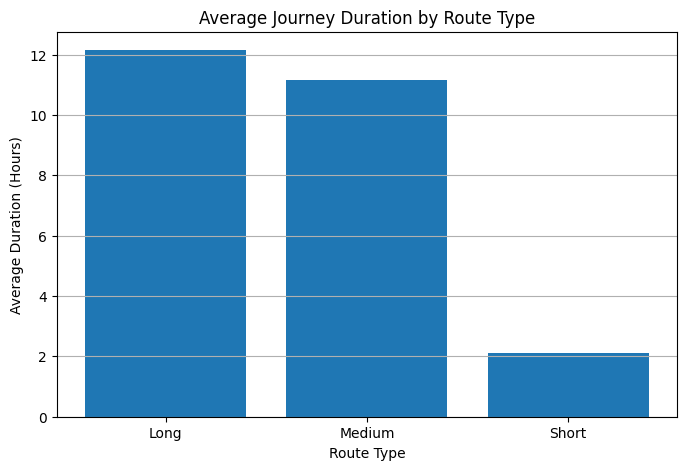

In [34]:
#Visualization 1: Average Journey Duration by Route Type
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    avg_duration['Route_Type'],
    avg_duration['Duration_Hours']
)

plt.title('Average Journey Duration by Route Type')
plt.xlabel('Route Type')
plt.ylabel('Average Duration (Hours)')
plt.grid(axis='y')

plt.show()

In [35]:
#Save Chart
plt.savefig(
    'avg_journey_duration.png',
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

Task 4.2: Identify High-Traffic Stations

In [36]:
top_stations = station_frequency.head(10)

print(top_stations)

      Station_Name  Train_Frequency
1755    CST-MUMBAI             1027
3466     KALYAN JN              828
7509         THANE              796
6834       SEALDAH              745
1592  CHENNAI BEAC              738
2950    HOWRAH JN.              699
1773         DADAR              598
2213   DUM DUM JN.              463
4245         KURLA              462
7401      TAMBARAM              434


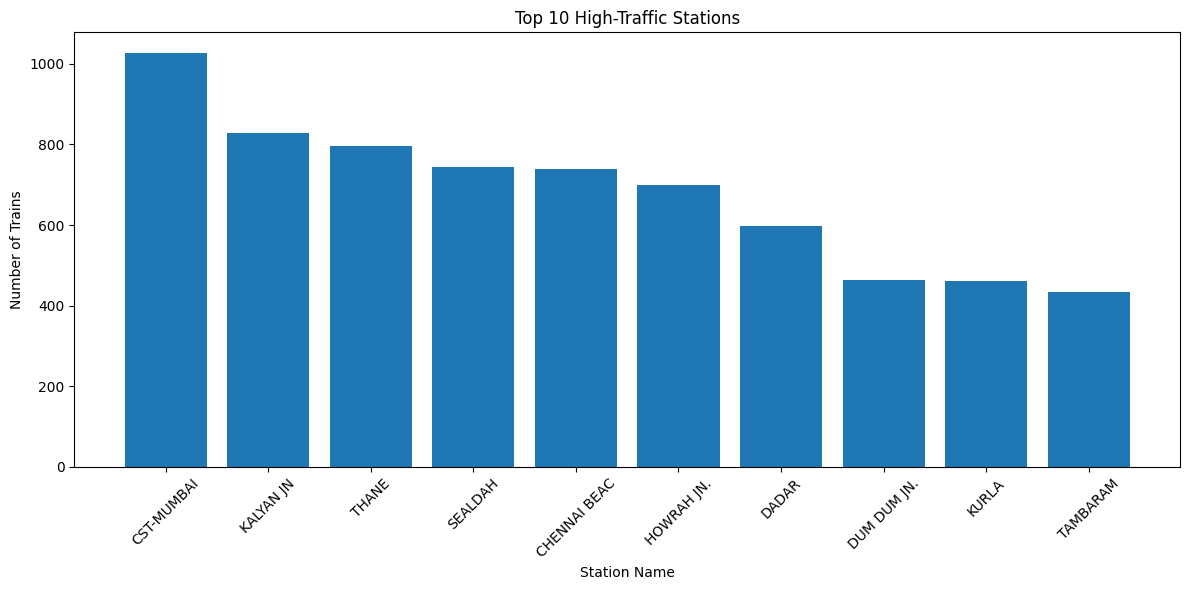

In [37]:
#Visualization 2: Top 10 High-Traffic Stations
plt.figure(figsize=(12,6))

plt.bar(
    top_stations['Station_Name'],
    top_stations['Train_Frequency']
)

plt.title('Top 10 High-Traffic Stations')
plt.xlabel('Station Name')
plt.ylabel('Number of Trains')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [38]:
#Save Chart
plt.savefig(
    'high_traffic_stations.png',
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

Task 4.3: Additional Visualization (Optional but Recommended)

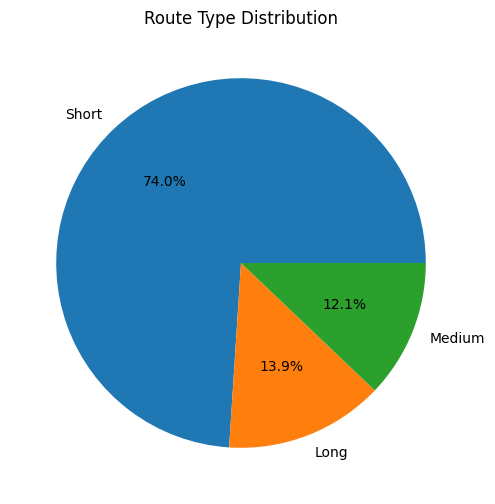

In [39]:
#Route Type Distribution
route_counts = route_distance[
    'Route_Type'
].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    route_counts,
    labels=route_counts.index,
    autopct='%1.1f%%'
)

plt.title('Route Type Distribution')

plt.show()

Task 4.4: Summarize Key Observations

Observation 1: Long Routes Have the Highest Average Journey Duration
-Long-distance routes recorded an average journey duration of 12.15 hours, which is the highest among all route categories.

Observation 2: Medium Routes Have Similar Travel Times
-Medium routes showed an average duration of 11.14 hours, indicating that many medium-distance trains still require significant travel time due to multiple stops and operational factors.

Observation 3: Short Routes Are Significantly Faster
-Short routes recorded an average duration of only 2.11 hours, making them the fastest category in the dataset.

Observation 4: Mumbai Region Dominates Train Traffic
-ST-MUMBAI emerged as the busiest station with 1,027 trains, followed by KALYAN JN (828) and THANE (796). This highlights the importance of Mumbai's railway network.

Observation 5: Major Metropolitan Hubs Handle High Traffic
-Stations such as SEALDAH (745), CHENNAI BEACH (738), and HOWRAH JN. (699) are among the busiest stations, indicating strong railway connectivity in major metropolitan regions.

Observation 6: Suburban Junctions Play a Critical Role
-Stations like DADAR, KURLA, and TAMBARAM appear in the top 10 list, showing that suburban junctions are important traffic distribution centers.

In [40]:
#Save Analysis Outputs
avg_duration.to_csv(
    'avg_duration_by_route.csv',
    index=False
)

top_stations.to_csv(
    'top_10_stations.csv',
    index=False
)

Level 5: Advanced Analysis and Visualization

Task 5.1: Pivot Table for Station-wise Train Distribution

In [41]:
pivot_station = pd.pivot_table(
    df,
    index='Station_Name',
    values='Train_No',
    aggfunc='nunique'
)

pivot_station.columns = ['Train_Count']

pivot_station = pivot_station.sort_values(
    by='Train_Count',
    ascending=False
)

pivot_station.head(15)

,Train_Count
Station_Name,
CST-MUMBAI,1027
KALYAN JN,828
THANE,796
SEALDAH,745
CHENNAI BEAC,738
HOWRAH JN.,699
DADAR,598
DUM DUM JN.,463
KURLA,462


In [42]:
#Save Output
pivot_station.to_csv(
    "pivot_station_distribution.csv"
)

Task 5.2: Cross-tabulation Between Route Type and Train Frequency

In [43]:
#Create Route Classification Dataset
route_info = route_distance[['Train_No','Route_Type']]

In [44]:
#Merge With Main Dataset
merged_df = pd.merge(
    df,
    route_info,
    on='Train_No'
)

In [45]:
#Cross-tabulation
route_station_crosstab = pd.crosstab(
    merged_df['Route_Type'],
    merged_df['Station_Name']
)

route_station_crosstab.head()

Station_Name,.BAGHAJATIN,ABADA,ABHAIPUR,ABHANPUR JN.,ABHAYAPURI A,ABJUGANJ,ABOHAR,ABU ROAD,ABUTARA HALT,ACHAL GANJ,...,ZAMANIA,ZAMPANI HALT,ZANGALAPALLE,ZARAP,ZERPUR PALI,ZINDPURA (HA,ZORAWARPURA,meghpur tito,saundal,veravali
Route_Type,,,,,,,,,,,,,,,,,,,,,
Long,0,0,32,0,0,0,4,90,0,0,...,24,0,0,0,0,0,0,0,0,0
Medium,0,1,11,0,2,0,16,8,0,0,...,0,2,6,2,4,0,0,2,2,2
Short,217,89,19,12,4,6,8,2,6,6,...,12,8,2,2,10,8,5,0,2,2


In [47]:
#Save Output
route_station_crosstab.to_csv(
    "route_station_crosstab.csv"
)

Task 5.3: Advanced Visualizations

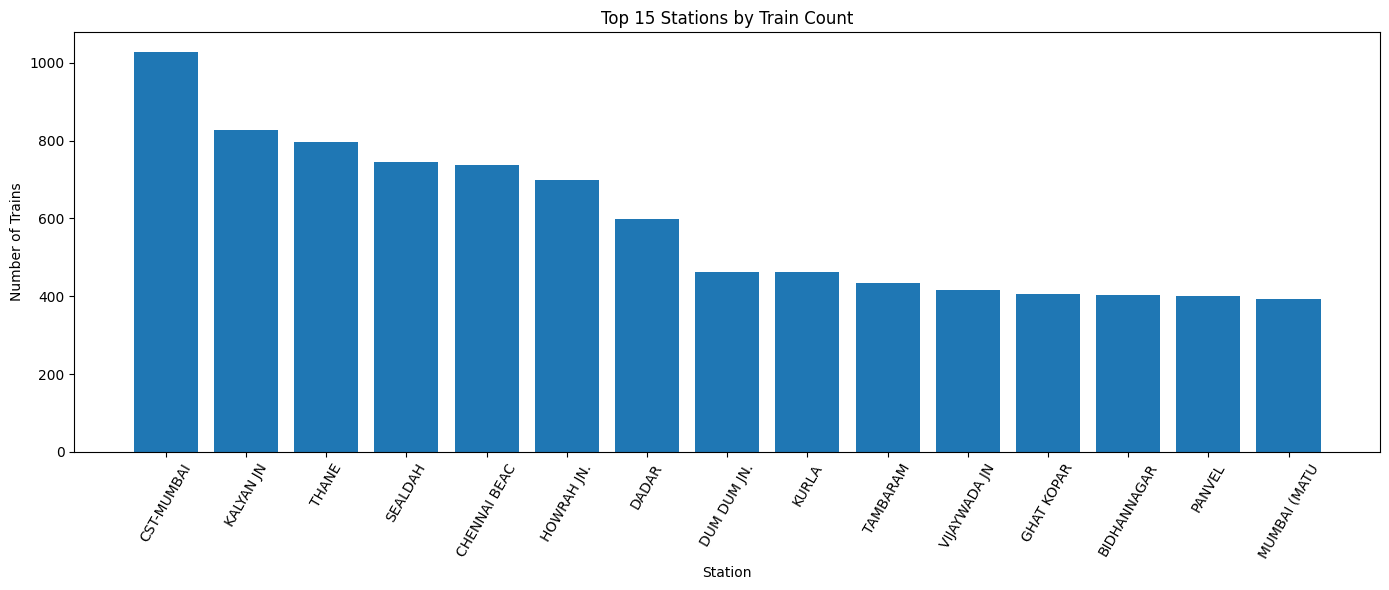

In [48]:
#Visualization 1: Top 15 Stations
import matplotlib.pyplot as plt

top15 = pivot_station.head(15)

plt.figure(figsize=(14,6))

plt.bar(
    top15.index,
    top15['Train_Count']
)

plt.xticks(rotation=60)

plt.title(
    'Top 15 Stations by Train Count'
)

plt.xlabel('Station')
plt.ylabel('Number of Trains')

plt.tight_layout()
plt.show()

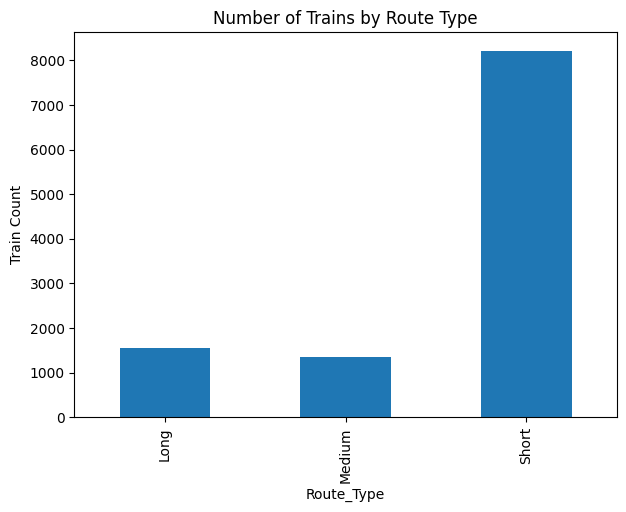

In [49]:
#Visualization 2: Route Type Distribution
route_summary = merged_df.groupby(
    'Route_Type'
)['Train_No'].nunique()

plt.figure(figsize=(7,5))

route_summary.plot(
    kind='bar'
)

plt.title(
    'Number of Trains by Route Type'
)

plt.ylabel('Train Count')

plt.show()

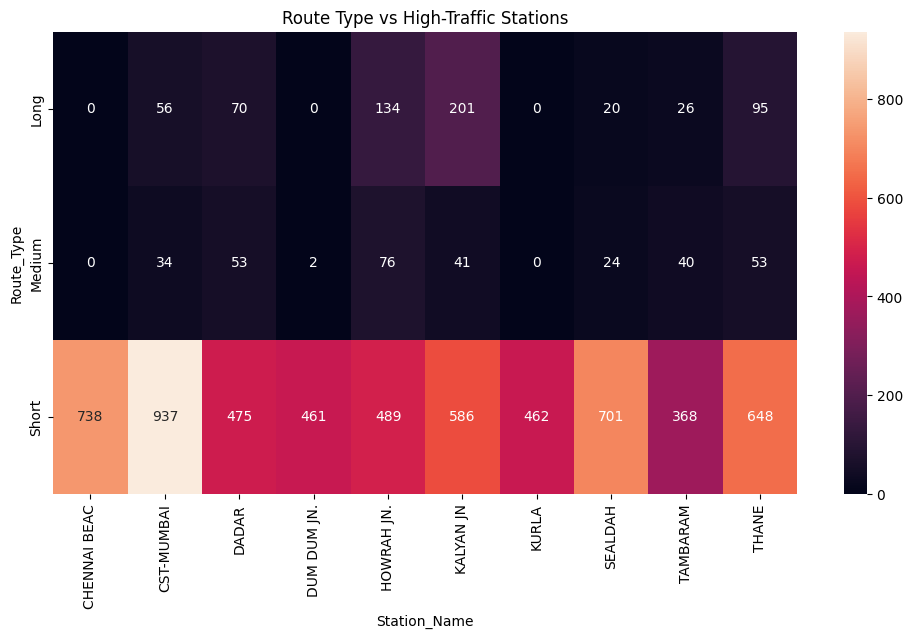

In [50]:
#Visualization 3: Heatmap 
import seaborn as sns

top_stations_list = station_frequency.head(10)['Station_Name']

heatmap_data = pd.crosstab(
    merged_df['Route_Type'],
    merged_df['Station_Name']
)

heatmap_data = heatmap_data[
    heatmap_data.columns.intersection(top_stations_list)
]

plt.figure(figsize=(12,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='d'
)

plt.title(
    'Route Type vs High-Traffic Stations'
)

plt.show()

Task 5.4: Advanced Insights

In [51]:
print(route_summary)

Route_Type
Long      1546
Medium    1346
Short     8221
Name: Train_No, dtype: int64


In [52]:
pivot_station.head(15)

,Train_Count
Station_Name,
CST-MUMBAI,1027
KALYAN JN,828
THANE,796
SEALDAH,745
CHENNAI BEAC,738
HOWRAH JN.,699
DADAR,598
DUM DUM JN.,463
KURLA,462


Level 6: Final Capstone System

In [53]:
import pandas as pd

df = pd.read_csv("Verified_Train_Dataset.csv")

# Sort data properly
df = df.sort_values(['Train_No', 'Distance'])

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [54]:
#Step 2: Interactive Train Enquiry System
import pandas as pd

df = pd.read_csv("Verified_Train_Dataset.csv")

df = df.sort_values(['Train_No', 'Distance'])

source = input("Enter Source Station: ").strip().upper()
destination = input("Enter Destination Station: ").strip().upper()

found = False

for train_no, group in df.groupby('Train_No'):

    stations = group['Station_Name'].str.upper().tolist()

    if source in stations and destination in stations:

        source_index = stations.index(source)
        dest_index = stations.index(destination)

        if source_index < dest_index:

            source_row = group.iloc[source_index]
            dest_row = group.iloc[dest_index]

            distance = (
                dest_row['Distance']
                - source_row['Distance']
            )

            print("\n========================")
            print("Train Number :", train_no)
            print("Source       :", source)
            print("Destination  :", destination)
            print("Distance     :", distance, "km")
            print("========================")

            found = True

if not found:
    print("\nNo Direct Train Found")

Enter Source Station:  THANE
Enter Destination Station:  KALYAN JN



Train Number : 1011
Source       : THANE
Destination  : KALYAN JN
Distance     : 20 km

Train Number : 11007
Source       : THANE
Destination  : KALYAN JN
Distance     : 20 km

Train Number : 11009
Source       : THANE
Destination  : KALYAN JN
Distance     : 20 km

Train Number : 11011
Source       : THANE
Destination  : KALYAN JN
Distance     : 20 km

Train Number : 11013
Source       : THANE
Destination  : KALYAN JN
Distance     : 20 km

Train Number : 11015
Source       : THANE
Destination  : KALYAN JN
Distance     : 20 km

Train Number : 11017
Source       : THANE
Destination  : KALYAN JN
Distance     : 20 km

Train Number : 11029
Source       : THANE
Destination  : KALYAN JN
Distance     : 20 km

Train Number : 11041
Source       : THANE
Destination  : KALYAN JN
Distance     : 20 km

Train Number : 11043
Source       : THANE
Destination  : KALYAN JN
Distance     : 20 km

Train Number : 11053
Source       : THANE
Destination  : KALYAN JN
Distance     : 20 km

Train Number : 11055


Project Conclusion :
The Train Schedule Analysis and Interactive Route Enquiry System was successfully developed using Python and Pandas. The project involved data exploration, preprocessing, quality validation, visualization, and advanced analytical techniques. An interactive enquiry system was implemented to allow users to search for direct train routes between stations and obtain journey information. The project demonstrated practical skills in data analysis, data cleaning, visualization, and application development.